<a href="https://colab.research.google.com/github/Clover130/Seismic-Babes-Group-Project-1/blob/main/EMSC2010_Group_Project_1_Seismic_Babes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EMSC2010 Seismic Babes Group Project 1

## 1. Project Overview
Group name: Seismic Babes

Project week: Week 5

Project title: Crustal Thickness of Australia and South America

Datasets used (name and source): GPlatesPortal, Crustal and Lithospheric Thickness {https://portal.gplates.org/cesium/?view=crustal_litho_thickness}

## 2. Roles and contributions

| Role | Primary | Deputy | Completed? | Notes |
| :--- | :--- | :--- | :--- | :--- |
| Github & integration | Clover | Owen | Yes/Partial/No| Add note|
| Data steward | Freddie | Clover | Yes/Partial/No| Add note|
| Analysis / modelling | Ed | Freddie | Yes/Partial/No| Add note|
| Visualisation / interpretation | Ellie | Justin | Yes/Partial/No| Add note|
| Narrative | Justin | Ellie | Yes/Partial/No| Add note|
| Quality Control / Reproducibility  | Owen | Ed | Yes/Partial/No/NA| Add note|


## 3. Deputy Interventions (if applicable)
Repeat text as required.

* Role affected:

* Reason (e.g. missed deadline, absence, etc.):

* Deputy action taken:

* Impact on workflow:

*N.B., this section should be factual, not judgemental.*

## 4. Pre-submission checklist
* Notebook runs from top to bottom.
* Datafiles are included in the GitHub repository.
* Commits include meaningful information.
* Each group member has included a brief reflection in the notebook.
* Repository has been shared with the teaching team once your project is completed.

# Start your group project here

#Question

## Project Question

Comparing the crustal densities of the Australian and South American continents

#Method

## Data Import

We created 2 tables in an Excel file, one containing the randomly generated coordinates located on the South American Continent and the other containing the Australian points. I then took these coordinates and used the program Gplates bu Cesium, to find the continental crust thickness at these specific coordinates. We used 40 points for each continent, so I repeated this process 40 times.  - Freddie

In [ ]:
import pandas as pd

# Load the Excel file
file_name = "CrustalThicknessData.xlsx"

# Read the entire sheet (no headers yet)
df = pd.read_excel(file_name, header=None)

# Find blank rows (separator between tables)
blank_rows = df[df.isnull().all(axis=1)].index

# Split into two tables
table1 = df.iloc[:blank_rows[0]].reset_index(drop=True)
table2 = df.iloc[blank_rows[0] + 1:].reset_index(drop=True)

# Set first row as header
table1.columns = table1.iloc[0]
table1 = table1[1:].reset_index(drop=True)

table2.columns = table2.iloc[0]
table2 = table2[1:].reset_index(drop=True)

# Display tables
print("Table 1:")
display(table1)

print("\nTable 2:")
display(table2)

FileNotFoundError: [Errno 2] No such file or directory: 'CrustalThicknessData.xlsx'

## Data Analysis

{Apply bootstrapping techniques, confidence intervals} - Ed

In [ ]:
import numpy as np
X = np.array([41650,35805,41730,39536,36919,36826,37092,38840,40287,31435,44002,33410,39714,29944,35409,36203,42251,34643,30536,36956,32064,39604,34553,33392,35733,30523,37063,37283,32012,40541,37957,31746,37813,35544,36306,34501,31625,40057,33640,32003])

In [ ]:
B = np.random.choice(X, size=(len(X),1000), replace=True)
print(np.shape(B))

(40, 1000)


In [ ]:
bar = np.mean(B, axis=0)
print(np.shape(bar))

(1000,)


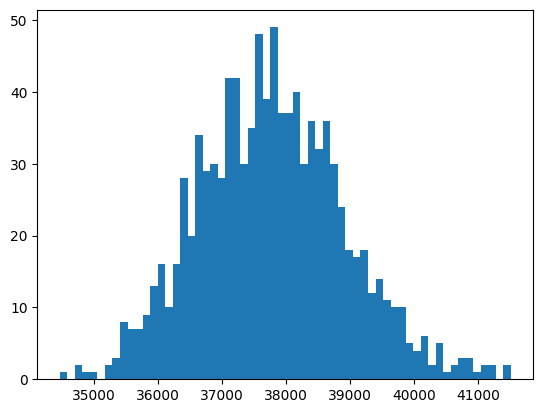

In [ ]:
import matplotlib.pyplot as plt

plt.hist(bar, bins=3);

In [ ]:
CI = np.percentile(bar,[2.5,97.5])
print(CI)

[35647.03875  40168.293125]


In [ ]:
Y = np.array([34322,35293,35039,39410,35067,35280,35828,55091,32356,36503,35437,36176,29607,39611,38196,20095,29776,60654,39834,32626,40245,35027,61185,39174,37772,37345,37636,35915,36660,40062,41767,44928,33984,36122,36792,36381,34633,36011,34524,39377])

In [ ]:
B = np.random.choice(X, size=(len(X),1000), replace=True)
print(np.shape(B))

(40, 1000)


In [ ]:
bar = np.mean(B, axis=0)
print(np.shape(bar))

(1000,)


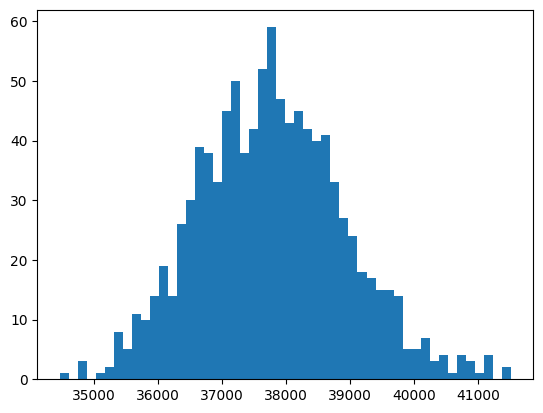

In [ ]:
plt.hist(bar, bins=50);

In [ ]:
CI = np.percentile(bar,[2.5,97.5])
print(CI)

[35647.03875  40168.293125]


#Results

## Data Visualisation

{produce plots} - Ellie

In [ ]:
!apt-get install -qq libgdal-dev libgeos-dev libproj-dev
!pip install cartopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 46.5 MB/s eta 0:00:00


In [ ]:
import pandas as pd #used to read and clean data
import matplotlib.pyplot as plt #used for data plotting
import cartopy.crs as ccrs #import map coordinate reference systems
import cartopy.feature as cfeature #imports Cartopy's map features

In [ ]:
spreadsheet_name = 'Seismic Babes_Group Project 1_DataSet.xlsx'
worksheet_AU = 'AU' # The sheet name containing Australian Crustal Thickness data
worksheet_SA = 'SA' # The sheet name containing South American Crustal Thickness data

df_AU = pd.read_excel(spreadsheet_name, sheet_name=worksheet_AU) #read the Australian  data into a dataframe
df_SA = pd.read_excel(spreadsheet_name, sheet_name=worksheet_SA) #read the South American data into a dataframe

In [ ]:
df_AU.head() #show the dataframe table for EQ

,Longitude,Latitude,Crustal Thickness (km)
0,136.319401,-17.498567,41650
1,148.713268,-37.032490,35805
2,130.425892,-20.041320,41730
3,150.284505,-35.797133,39536
4,135.198613,-32.668681,36919


In [ ]:
df_SA.head()

,Longitude,Latitude,Crustal Thickness (km)
0,-74.496015,-49.550410,34322
1,-55.125278,-27.827940,35293
2,-57.220806,-4.890713,35039
3,-46.871095,-13.320275,39410
4,-51.014127,-3.364726,35067


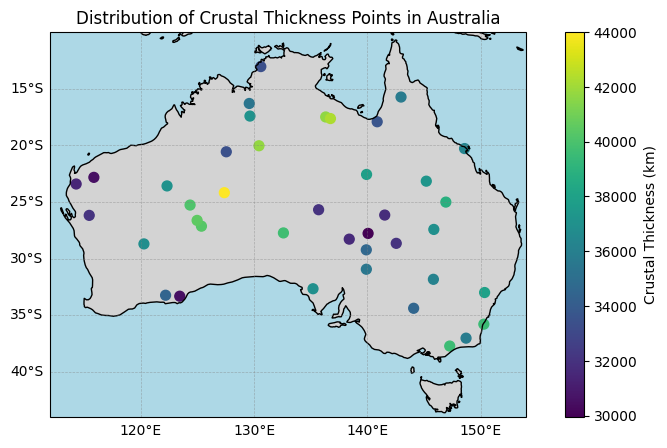

In [ ]:
# MAP SETUP & ADD FEATURES

# Define the map projection to use Lambert Conformal
my_projection=ccrs.PlateCarree()

# Create a Matplotlib figure with a width of 10 inches and height of 5 inches
fig = plt.figure(figsize=(10, 5))

# Create a map axis using the chosen Cartopy projection
ax = plt.axes(projection=my_projection)

# Draw coastlines on the map for geographic reference
ax.coastlines()

# Set the map extent to cover the entire globe
ax.set_extent([112, 154, -44, -10], crs=ccrs.PlateCarree()) #limit map to show Australia

# Add land areas to the map and color them light gray
ax.add_feature(cfeature.LAND, facecolor="lightgray")

# Add ocean areas to the map and color them light blue
ax.add_feature(cfeature.OCEAN, facecolor="lightblue")

# --------------------------------------------------
# PLOT EARTHQUAKE LOCATIONS (MAGNITUDE SHOWN AS COLOUR)
# --------------------------------------------------

# Plot earthquake locations as a scatter plot (brackets split one line of code into multiple for readability)
sc_AU = ax.scatter(
    df_AU['Longitude'], # Longitudes of earthquakes (x-coordinates)
    df_AU['Latitude'], # Latitudes of earthquakes (y-coordinates)
    c=df_AU['Crustal Thickness (km)'], # Color the markers by earthquake depth
    s=50, # Scale marker size by earthquake magnitude
    cmap="viridis", # Use the 'viridis' colormap for depth values
    transform=ccrs.PlateCarree()  # Specify that the input coordinates are in Plate Carrée (lon/lat) projection
)

# This shows how marker color corresponds to crustal thickness
plt.colorbar(sc_AU, label="Crustal Thickness (km)")

# Add a title to the figure
plt.title("Distribution of Crustal Thickness Points in Australia")

# --------------------------------------------------
# ADD GRIDLINES AND LABELS
# --------------------------------------------------

# Add latitude and longitude gridlines to the map
gl = ax.gridlines(
    draw_labels=True,     # Show coordinate labels on the map edges
    linewidth=0.5,        # Set gridline thickness
    color="gray",         # Set gridline color
    alpha=0.5,            # Make gridlines semi-transparent
    linestyle="--"        # Use dashed gridlines
)

# Disable labels at the top of the map
gl.top_labels = False

# Disable labels on the right side of the map
gl.right_labels = False

plt.show()

## Interpretation/Discussion

{discuss/compare results}

#Individual Reflections

###Freddie (Data Steward)

###Ed (Analysis Modelling)

###Ellie (Visualisation/Interpretation)

###Justin (Narrative)

###Owen (Quality Control/Reproducibility)